In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from scipy.stats import ks_2samp
from sklearn.svm import SVR
import xgboost as xgb
import joblib
import os
import re

: 

In [7]:
#@title NASA Power paramters
parameters_dict = {
    'Temperature at 2 Meters': 'T2M',
    'All Sky Surface Shortwave Downward Irradiance': 'ALLSKY_SFC_SW_DWN',
    'Relative Humidity at 2 Meters': 'RH2M',
    'Wind Speed at 2 Meters': 'WS2M',
    'Dew/Frost Point at 2 Meters': 'T2MDEW',
    'Temperature at 2 Meters Maximum': 'T2M_MAX',
    'Temperature at 2 Meters Minimum': 'T2M_MIN',
    'Surface Pressure': 'PS',
    'Wet Bulb Temperature at 2 Meters': 'T2MWET',
    'All Sky Surface Longwave Downward Irradiance': 'ALLSKY_SFC_LW_DWN',
    'All Sky Surface Shortwave Diffuse Irradiance': 'ALLSKY_SFC_SW_DIFF',
    'All Sky Surface Shortwave Downward Direct Normal Irradiance': 'ALLSKY_SFC_SW_DNI',
    'All Sky Surface Albedo': 'ALLSKY_SRF_ALB',
    'Cloud Amount': 'CLOUD_AMT',
    'Precipitation Corrected': 'PRECTOTCORR',
    'Top-Of-Atmosphere Shortwave Downward Irradiance': 'TOA_SW_DWN',
    'Profile Soil Moisture': 'GWETPROF',
    'Earth Skin Temperature': 'TS',
    'All Sky Surface Total PAR': 'ALLSKY_SFC_PAR_TOT',
    'Specific Humidity at 2 Meters': 'QV2M',
    'Temperature at 2 Meters Range': 'T2M_RANGE',
    'All Sky Insolation Clearness Index': 'ALLSKY_KT',
    'Clear Sky Surface Shortwave Downward Irradiance': 'CLRSKY_SFC_SW_DWN',
    'Root Zone Soil Wetness': 'GWETROOT',
    'Surface Soil Wetness': 'GWETTOP',
    'All Sky Surface UVA Irradiance': 'ALLSKY_SFC_UVA',
    'All Sky Surface UVB Irradiance': 'ALLSKY_SFC_UVB',
    'All Sky Surface UV Index': 'ALLSKY_SFC_UV_INDEX',
    'Clear Sky Insolation Clearness Index': 'CLRSKY_KT',
    'Clear Sky Surface Total PAR': 'CLRSKY_SFC_PAR_TOT',
    'Precipitable Water': 'PW',
    'Air Mass': 'AIRMASS',
    'All Sky Normalized Insolation Clearness Index': 'ALLSKY_NKT',
    'All Sky Surface Longwave Upward Irradiance': 'ALLSKY_SFC_LW_UP',
    'All Sky Surface Diffuse PAR': 'ALLSKY_SFC_PAR_DIFF',
    'All Sky Surface Direct Horizontal PAR': 'ALLSKY_SFC_PAR_DIRH',
    'All Sky Surface Shortwave Direct Horizontal Irradiance': 'ALLSKY_SFC_SW_DIRH',
    'All Sky Surface Shortwave Upward Irradiance': 'ALLSKY_SFC_SW_UP',
    'Adjusted Aerosol Optical Depth 55': 'AOD_55_ADJ',
    'Aerosol Optical Depth 84': 'AOD_84',
    'Cloud Optical Visible Depth': 'CLOUD_OD',
    'Clear Sky Days': 'CLRSKY_DAYS',
    'Clear Sky Normalized Insolation Clearness Index': 'CLRSKY_NKT',
    'Clear Sky Surface Longwave Downward Irradiance': 'CLRSKY_SFC_LW_DWN',
    'Clear Sky Surface Longwave Upward Irradiance': 'CLRSKY_SFC_LW_UP',
    'Clear Sky Surface Diffuse PAR': 'CLRSKY_SFC_PAR_DIFF',
    'Clear Sky Surface Direct Horizontal PAR': 'CLRSKY_SFC_PAR_DIRH',
    'Clear Sky Surface Shortwave Downward Diffuse Irradiance': 'CLRSKY_SFC_SW_DIFF',
    'Clear Sky Surface Shortwave Direct Horizontal Irradiance': 'CLRSKY_SFC_SW_DIRH',
    'Clear Sky Surface Shortwave Downward Direct Normal Irradiance': 'CLRSKY_SFC_SW_DNI',
    'Clear Sky Surface Shortwave Upward Irradiance': 'CLRSKY_SFC_SW_UP',
    'Clear Sky Surface Albedo': 'CLRSKY_SRF_ALB',
    'Zero Plane Displacement Height': 'DISPH',
    'Evaporation Land': 'EVLAND',
    'Evapotranspiration Energy Flux': 'EVPTRNS',
    'Ice Covered Fraction': 'FRSEAICE',
    'Planetary Boundary Layer Top Pressure': 'PBLTOP',
    'Peak Sun Hour': 'PSH',
    'Surface Air Density': 'RHOA',
    'Surface Albedo Adjusted': 'SRF_ALB_ADJ',
    'Total Column Ozone': 'TO3',
    'Total Column Precipitable Water': 'TQV',
    'Eastward Wind at 2 Meters': 'U2M',
    'Northward Wind at 2 Meters': 'V2M',
    'Surface Roughness': 'Z0M'
}
parameters_array = list(parameters_dict.values())
# add altitude to parameters
parameters_array.append('altitude')

# Temperature Parameters
temperature_params = [
    "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "T2MWET", "T2M_RANGE", "TS"
]

temperature_params_cleaned = [
    "T2M", "T2MDEW", "T2M_RANGE"
]

# Irradiance Parameters
irradiance_params = [
 'ALLSKY_SFC_LW_UP',
 'ALLSKY_SFC_PAR_DIFF',
 'ALLSKY_SFC_PAR_DIRH',
 'ALLSKY_SFC_PAR_TOT',
 'ALLSKY_SFC_SW_DIFF',
 'ALLSKY_SFC_SW_DIRH',
 'ALLSKY_SFC_SW_DNI',
 'ALLSKY_SFC_SW_DWN',
 'ALLSKY_SFC_SW_UP',
 'CLRSKY_SFC_LW_DWN',
 'CLRSKY_SFC_LW_UP',
 'CLRSKY_SFC_PAR_DIFF',
 'CLRSKY_SFC_PAR_DIRH',
 'CLRSKY_SFC_PAR_TOT',
 'CLRSKY_SFC_SW_DIFF',
 'CLRSKY_SFC_SW_DIRH',
 'CLRSKY_SFC_SW_DNI',
 'CLRSKY_SFC_SW_DWN',
 'CLRSKY_SFC_SW_UP',
]

irradiance_params_cleaned = [
    "ALLSKY_SFC_SW_DWN", "TOA_SW_DWN",
    "ALLSKY_SFC_SW_UP",  "CLRSKY_SFC_SW_DIFF", "CLRSKY_SFC_SW_DNI"
]

# Humidity and Moisture Parameters
humidity_params = [
    "RH2M", "QV2M", "GWETPROF", "GWETROOT", "GWETTOP", "PW", "TQV"
]

humidity_params_cleaned = [
    "RH2M", "QV2M", "GWETPROF", "GWETTOP", "PW", "TQV"
]

# Wind Parameters
wind_params = [
    "WS2M", "U2M", "V2M"
]

wind_params_cleaned = [
    "WS2M", "U2M", "V2M"
]

# Cloud and Aerosol Parameters
cloud_aerosol_params = [
    "CLOUD_AMT", "CLOUD_OD", "AOD_55_ADJ", "AOD_84"
]

cloud_aerosol_params_cleaned = [
    "CLOUD_AMT", "CLOUD_OD", "AOD_55_ADJ"
]

# Surface and Atmospheric Pressure Parameters
pressure_params = [
    "PS", "PBLTOP"
]

pressure_params_cleaned = [
    "PS", "PBLTOP"
]
# Albedo and Reflectance Parameters
albedo_params = [
    "ALLSKY_SRF_ALB", "CLRSKY_SRF_ALB", "SRF_ALB_ADJ"
]

albedo_params_cleaned = ['SRF_ALB_ADJ']
# Precipitation and Water Parameters
precipitation_params = [
    "PRECTOTCORR", "EVLAND", "EVPTRNS"
]

precipitation_params_cleaned = [
    "PRECTOTCORR", "EVLAND", "EVPTRNS"
]
# Solar Radiation and Clearness Index Parameters
clearness_index_params = [
    "ALLSKY_KT", "CLRSKY_KT", "ALLSKY_NKT", "CLRSKY_NKT"
]

clearness_index_params_cleaned = [
    "ALLSKY_KT"
]
# UV Radiation Parameters
uv_params = [
    "ALLSKY_SFC_UVA", "ALLSKY_SFC_UVB", "ALLSKY_SFC_UV_INDEX"
]

uv_params_cleaned = [
    "ALLSKY_SFC_UVA", "ALLSKY_SFC_UVB", "ALLSKY_SFC_UV_INDEX"
]
# Photosynthetically Active Radiation (PAR) Parameters
par_params = [
    "ALLSKY_SFC_PAR_TOT", "CLRSKY_SFC_PAR_TOT", "ALLSKY_SFC_PAR_DIFF",
    "ALLSKY_SFC_PAR_DIRH", "CLRSKY_SFC_PAR_DIFF", "CLRSKY_SFC_PAR_DIRH"
]

par_params_cleaned = [
    "ALLSKY_SFC_PAR_TOT"
]

# Other Meteorological Parameters
other_params = [
    "TO3", "RHOA", "Z0M", "DISPH"
]

other_params_cleaned = [
    "TO3", "RHOA", "Z0M", "DISPH"
]

cleaned_params = []
# add altitude
cleaned_params.append('altitude')
for param in parameters_array:

    # add temperature cleaned
    if param in temperature_params_cleaned:
        cleaned_params.append(param)

    # # add irradiance cleaned
    # if param in irradiance_params_cleaned:
    #     cleaned_params.append(param)

    # # add humidity cleaned
    # if param in humidity_params_cleaned:
    #     cleaned_params.append(param)

    # add wind cleaned
    if param in wind_params_cleaned:
        cleaned_params.append(param)

    # add cloud and aerosol cleaned
    if param in cloud_aerosol_params_cleaned:
        cleaned_params.append(param)

    # add pressure cleaned
    if param in pressure_params_cleaned:
        cleaned_params.append(param)

    # add albedo cleaned
    if param in albedo_params_cleaned:
        cleaned_params.append(param)

    # # add precipitation cleaned
    # if param in precipitation_params_cleaned:
    #     cleaned_params.append(param)

    # # add clearness index cleaned
    # if param in clearness_index_params_cleaned:
    #     cleaned_params.append(param)

    # # add par cleaned
    # if param in par_params_cleaned:
    #     cleaned_params.append(param)

    # add other cleaned
    if param in other_params_cleaned:
        cleaned_params.append(param)

In [8]:
#@title Plot
def parse_and_plot_metrics(latex_table: str, title:str='Model Performance Metrics'):
    """
    Parses a LaTeX-style table string and plots model metrics in a single grouped bar chart.

    Args:
        latex_table (str): A string containing the LaTeX-formatted table.
    """

    # Extract lines that contain data
    lines = latex_table.strip().splitlines()

    # Skip header lines
    data_lines = [line for line in lines if '&' in line and not ('Model' in line or 'midrule' in line)]

    # Prepare lists
    models = []
    rmse = []
    mae = []
    r2 = []
    mbe = []
    ksi = []

    # Parse each line
    for line in data_lines:
        # Remove LaTeX commands like \textbf{} and \\
        line_clean = re.sub(r'\textbf{(.*?)}', r'\1', line)
        line_clean = line_clean.replace('\\', '').strip()

        # Split on '&' and strip spaces
        parts = [p.strip() for p in line_clean.split('&')]

        # Append to lists
        models.append(parts[0])
        rmse.append(float(parts[1]))
        mae.append(float(parts[2]))
        r2.append(float(parts[3]))
        mbe.append(float(parts[4]))
        ksi.append(float(parts[5]))

    # Create DataFrame
    df = pd.DataFrame({
        'Model': models,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MBE': mbe,
        'KSI': ksi
    })

    # Melt the DataFrame for easier grouped plotting
    df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Value")

    # Plotting
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 8))
    sns.barplot(x="Model", y="Value", hue="Metric", data=df_melted, palette="viridis")

    plt.title(title, fontsize=16)
    plt.xlabel('Model')
    plt.ylabel('Metric Value')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

In [9]:
#@title Pipeline

def calculate_metrics(y_true, y_pred, model_name="Model", verbose=True, latex=True):
    """
    Calculates standard regression metrics including the Kolmogorov-Smirnov statistic (KSI).

    Args:
        y_true (array-like): Ground truth values.
        y_pred (array-like): Predicted values.
        model_name (str): Name of the model for printing.
        verbose (bool): Whether to print the metrics.
        latex (bool): Whether to print the metrics in LaTeX table format.

    Returns:
        dict: Dictionary containing the calculated metrics: RMSE, MAE, R2, MBE, KSI.
    """
    print(f"--- {model_name} Performance ---")
    # Ensure inputs are numpy arrays for consistency
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mbe = np.mean(y_pred - y_true)
    ks_stat, _ = ks_2samp(y_true, y_pred)

    if verbose:
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        print(f"MBE:  {mbe:.4f}")
        print(f"KSI:  {ks_stat:.4f}") # Print KSI
        print("-" * (len(model_name) + 20))

    if latex:
        print('Latex version')
        # Add KSI to the latex output
        print(f'{rmse:.4f} & {mae:.4f} & {r2:.4f} & {mbe:.4f} & {ks_stat:.4f}\n')

    # Add KSI to the returned dictionary
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "MBE": mbe, "KSI": ks_stat}

def plot_ghi_comparison(index, y_true, y_corrected, y_est, num_points=100, title="GHI Comparison"):
    """Plots the comparison of different GHI estimates."""
    plt.figure(figsize=(15, 6))
    plt.plot(index[:num_points], y_corrected[:num_points], label='Corrected GHI (Model Output)', marker='.', linestyle='-', markersize=4)
    plt.plot(index[:num_points], y_true[:num_points], label='Ground Truth GHI', marker='x', linestyle='--', markersize=4)
    plt.plot(index[:num_points], y_est[:num_points], label='Original est GHI', marker='o', linestyle=':', markersize=4, alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel("GHI (W/m²)")
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

class SolarGHIErrorCorrection:
    """
    A class to handle the training, evaluation, and prediction for GHI error correction models.
    This allows saving the model and reusing it for future predictions without retraining.
    """

    def __init__(self, model_type='random_forest', model_params=None, save_path=None, feature_cols=None, ground_truth_col='ghi', est_ghi_col='ALLSKY_SFC_SW_DWN'):
        """
        Initialize the error correction pipeline.

        Args:
            model_type (str): Type of model to use ('random_forest', 'linear', 'ridge', 'svr', 'xgboost')
            model_params (dict): Parameters for the selected model
            save_path (str): Directory to save the model and scaler
        """
        self.model_type = model_type
        self.model_params = model_params or {}
        self.save_path = save_path
        self.model = None
        self.scaler = None
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col
        self.is_trained = False

        # Create save directory if it doesn't exist
        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)

    def _create_model(self):
        """Create the model based on the specified type."""
        if self.model_type == 'random_forest':
            n_estimators = self.model_params.get('n_estimators', 100)
            random_state = self.model_params.get('random_state', 42)
            model_params_copy = self.model_params.copy()
            model_params_copy.pop('n_estimators', None)
            model_params_copy.pop('random_state', None)
            return RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=-1, **model_params_copy)

        elif self.model_type == 'linear':
            return LinearRegression(**self.model_params)

        elif self.model_type == 'ridge':
            if 'alpha' not in self.model_params:
                self.model_params['alpha'] = 1.0
            if 'solver' not in self.model_params:
                self.model_params['solver'] = 'auto'
            if 'max_iter' not in self.model_params:
                self.model_params['max_iter'] = 1000
            return Ridge(**self.model_params)

        elif self.model_type == 'svr':
            if 'kernel' not in self.model_params:
                self.model_params['kernel'] = 'rbf'
            if 'C' not in self.model_params:
                self.model_params['C'] = 1.0
            if 'epsilon' not in self.model_params:
                self.model_params['epsilon'] = 0.1
            return SVR(**self.model_params)

        elif self.model_type == 'xgboost':
            if 'n_estimators' not in self.model_params:
                self.model_params['n_estimators'] = 100
            if 'learning_rate' not in self.model_params:
                self.model_params['learning_rate'] = 0.1
            if 'max_depth' not in self.model_params:
                self.model_params['max_depth'] = 3
            if 'random_state' not in self.model_params:
                self.model_params['random_state'] = 42
            return xgb.XGBRegressor(**self.model_params)

        else:
            raise ValueError(f"Unsupported model type: {self.model_type}")

    def train(self, df, feature_cols, ground_truth_col='ghi', est_ghi_col='ALLSKY_SFC_SW_DWN',
              test_size=0.2, scale_features=False, plot_comparison=True, num_plot_points=100, verbose=True):
        """
        Train the model and optionally evaluate on a test set.

        Args:
            df (pd.DataFrame): DataFrame containing all necessary columns
            feature_cols (list): List of column names to use as features
            ground_truth_col (str): Name of the ground truth GHI column
            est_ghi_col (str): Name of the original est GHI column
            test_size (float): Proportion of the data to use for the test set
            scale_features (bool): Whether to apply StandardScaler to features
            plot_comparison (bool): Whether to plot the test set results
            num_plot_points (int): Number of points to show in the plot

        Returns:
            dict: A dictionary containing performance metrics and test set predictions
        """
        # Store column names for future predictions
        self.feature_cols = feature_cols
        self.ground_truth_col = ground_truth_col
        self.est_ghi_col = est_ghi_col

        # Create a fresh model instance
        self.model = self._create_model()

        # Process data
        df_processed = df.copy()
        df_processed = df_processed.dropna(subset=[ground_truth_col] + feature_cols)

        if df_processed.empty:
            print("Error: DataFrame is empty after dropping NaNs. Check input data.")
            return None

        # Calculate error (target)
        target_col = 'bias'
        df_processed[target_col] = df_processed[self.ground_truth_col] - df_processed[self.est_ghi_col]

        # Prepare features and target
        X = df_processed[feature_cols]
        y = df_processed[target_col]

        # Store original values for evaluation
        original_est_ghi = df_processed[est_ghi_col]
        original_ground_truth = df_processed[ground_truth_col]

        # Split into train/test
        n_samples = len(X)
        n_train = int(n_samples * (1 - test_size))

        X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
        y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

        # Keep corresponding original GHI values for test set evaluation
        est_ghi_test = original_est_ghi.iloc[n_train:]
        ground_truth_test = original_ground_truth.iloc[n_train:]
        test_index = ground_truth_test.index

        if X_train.empty or X_test.empty:
            print(f"Error: Train or test set is empty after split (Train: {len(X_train)}, Test: {len(X_test)})")
            return None

        # Feature scaling if requested
        if scale_features:
            self.scaler = StandardScaler()
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train the model
            print(f"\nTraining {self.model.__class__.__name__}...")
            self.model.fit(X_train_scaled, y_train)
        else:
            # Train without scaling
            print(f"\nTraining {self.model.__class__.__name__}...")
            self.model.fit(X_train, y_train)
            X_test_scaled = X_test

        print("Training complete.")
        self.is_trained = True

        # Save model and scaler if a path is provided
        if self.save_path:
            self._save_model()

        # Evaluate on test set
        error_pred_test = self.model.predict(X_test_scaled)
        ghi_corrected_test = error_pred_test + est_ghi_test

        # Calculate metrics
        if verbose:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth ---")
        model_metrics = calculate_metrics(ground_truth_test, ghi_corrected_test, self.model.__class__.__name__, verbose=verbose, latex=False)

        if verbose:
            print("\n--- Evaluating Original est GHI vs Ground Truth (Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth_test, est_ghi_test, "Baseline (est GHI)", verbose=verbose, latex=False)

        # Plot results if requested
        if plot_comparison:
            plot_ghi_comparison(
                test_index,
                ground_truth_test,
                ghi_corrected_test,
                est_ghi_test,
                num_points=num_plot_points,
                title=f"{self.model.__class__.__name__} GHI Correction Performance"
            )

        # Return results dictionary
        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics,
            "test_predictions": {
                "index": test_index,
                "ground_truth": ground_truth_test,
                "corrected_ghi": ghi_corrected_test,
                "est_ghi": est_ghi_test
            }
        }

    def predict(self, df, return_error=False):
        """
        Make predictions with the trained model.

        Args:
            df (pd.DataFrame): DataFrame containing the required feature columns and est GHI column
            return_error (bool): If True, return the predicted error instead of corrected GHI

        Returns:
            pd.Series: Corrected GHI values or predicted error values
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        if not all(col in df.columns for col in self.feature_cols + [self.est_ghi_col]):
            missing = set(self.feature_cols + [self.est_ghi_col]) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame: {missing}")

        # Drop rows with missing values in feature columns
        df_clean = df.dropna(subset=self.feature_cols + [self.est_ghi_col])

        # Extract features
        X = df_clean[self.feature_cols]

        # Apply scaling if needed
        if self.scaler is not None:
            X_scaled = self.scaler.transform(X)
        else:
            X_scaled = X

        # Predict error
        predicted_error = self.model.predict(X_scaled)

        if return_error:
            return pd.Series(predicted_error, index=df_clean.index)
        else:
            # Calculate corrected GHI
            est_ghi = df_clean[self.est_ghi_col].values
            corrected_ghi = est_ghi + predicted_error
            return pd.Series(corrected_ghi, index=df_clean.index)

    def evaluate(self, df, plot_results=True, num_plot_points=200, verbose=True, latex=True):
        """
        Evaluate model on new data that includes ground truth.

        Args:
            df (pd.DataFrame): DataFrame containing features, est GHI, and ground truth columns
            plot_results (bool): Whether to plot comparison
            num_plot_points (int): Number of points to show in the plot

        Returns:
            dict: Dictionary containing performance metrics
        """
        if not self.is_trained:
            raise RuntimeError("Model is not trained. Call train() first or load a saved model.")

        required_cols = self.feature_cols + [self.est_ghi_col, self.ground_truth_col]
        if not all(col in df.columns for col in required_cols):
            missing = set(required_cols) - set(df.columns)
            raise ValueError(f"Missing required columns in input DataFrame: {missing}")

        # Drop rows with missing values
        df_clean = df.dropna(subset=required_cols)

        # Get predictions
        corrected_ghi = self.predict(df_clean)

        # Extract ground truth and est GHI
        ground_truth = df_clean[self.ground_truth_col]
        est_ghi = df_clean[self.est_ghi_col]

        # Calculate metrics
        if verbose or latex:
            print("\n--- Evaluating Model Corrected GHI vs Ground Truth ---")
        model_metrics = calculate_metrics(ground_truth, corrected_ghi, self.model.__class__.__name__, verbose=verbose, latex=latex)

        if verbose or latex:
            print("\n--- Evaluating Original est GHI vs Ground Truth (Baseline) ---")
        baseline_metrics = calculate_metrics(ground_truth, est_ghi, "Baseline (est GHI)", verbose=verbose, latex=latex)

        # Plot results if requested
        if plot_results:
            plot_ghi_comparison(
                df_clean.index,
                ground_truth,
                corrected_ghi,
                est_ghi,
                num_points=num_plot_points,
                title=f"{self.model.__class__.__name__} GHI Correction Performance"
            )

        return {
            "model_performance": model_metrics,
            "baseline_performance": baseline_metrics
        }

    def _save_model(self):
        """Save the trained model and scaler."""
        if not self.is_trained:
            print("Warning: Attempting to save an untrained model")
            return

        if not self.save_path:
            print("Warning: No save path specified")
            return

        # Save model
        model_path = os.path.join(self.save_path, f"{self.model_type}_model.joblib")
        joblib.dump(self.model, model_path)

        # Save scaler if exists
        if self.scaler is not None:
            scaler_path = os.path.join(self.save_path, f"{self.model_type}_scaler.joblib")
            joblib.dump(self.scaler, scaler_path)

        # Save metadata (feature columns and other configuration)
        metadata = {
            'feature_cols': self.feature_cols,
            'ground_truth_col': self.ground_truth_col,
            'est_ghi_col': self.est_ghi_col,
            'model_type': self.model_type,
            'model_params': self.model_params
        }
        metadata_path = os.path.join(self.save_path, f"{self.model_type}_metadata.joblib")
        joblib.dump(metadata, metadata_path)

        print(f"Model saved to {self.save_path}")

    def load_model(self, model_dir=None):
        """
        Load a previously saved model and its metadata.

        Args:
            model_dir (str): Directory where the model was saved (defaults to self.save_path)
        """
        dir_path = model_dir or self.save_path
        if not dir_path:
            raise ValueError("No model directory specified")

        # Load model
        model_path = os.path.join(dir_path, f"{self.model_type}_model.joblib")
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found at {model_path}")

        self.model = joblib.load(model_path)

        # Load scaler if exists
        scaler_path = os.path.join(dir_path, f"{self.model_type}_scaler.joblib")
        if os.path.exists(scaler_path):
            self.scaler = joblib.load(scaler_path)

        # Load metadata
        metadata_path = os.path.join(dir_path, f"{self.model_type}_metadata.joblib")
        if os.path.exists(metadata_path):
            metadata = joblib.load(metadata_path)
            self.feature_cols = metadata['feature_cols']
            self.ground_truth_col = metadata['ground_truth_col']
            self.est_ghi_col = metadata['est_ghi_col']
            self.model_params = metadata['model_params']

        self.is_trained = True
        print(f"Model loaded from {dir_path}")

# Convenience factory functions
def create_linear_regression_model(save_path=None, feature_cols=None, ground_truth_col='ghi', 
                                  est_ghi_col='ALLSKY_SFC_SW_DWN', **kwargs):
    """Create a Linear Regression model instance."""
    return SolarGHIErrorCorrection(
        model_type='linear', 
        model_params=kwargs, 
        save_path=save_path,
        feature_cols=feature_cols,
        ground_truth_col=ground_truth_col,
        est_ghi_col=est_ghi_col
    )

def create_random_forest_model(save_path=None, feature_cols=None, ground_truth_col='ghi', 
                              est_ghi_col='ALLSKY_SFC_SW_DWN', **kwargs):
    """Create a Random Forest model instance."""
    return SolarGHIErrorCorrection(
        model_type='random_forest', 
        model_params=kwargs, 
        save_path=save_path,
        feature_cols=feature_cols,
        ground_truth_col=ground_truth_col,
        est_ghi_col=est_ghi_col
    )

def create_ridge_regression_model(save_path=None, feature_cols=None, ground_truth_col='ghi', 
                                 est_ghi_col='ALLSKY_SFC_SW_DWN', **kwargs):
    """Create a Ridge Regression model instance."""
    return SolarGHIErrorCorrection(
        model_type='ridge', 
        model_params=kwargs, 
        save_path=save_path,
        feature_cols=feature_cols,
        ground_truth_col=ground_truth_col,
        est_ghi_col=est_ghi_col
    )

def create_svr_model(save_path=None, feature_cols=None, ground_truth_col='ghi', 
                    est_ghi_col='ALLSKY_SFC_SW_DWN', **kwargs):
    """Create an SVR model instance."""
    return SolarGHIErrorCorrection(
        model_type='svr', 
        model_params=kwargs, 
        save_path=save_path,
        feature_cols=feature_cols,
        ground_truth_col=ground_truth_col,
        est_ghi_col=est_ghi_col
    )

def create_xgboost_model(save_path=None, feature_cols=None, ground_truth_col='ghi', 
                        est_ghi_col='ALLSKY_SFC_SW_DWN', **kwargs):
    """Create an XGBoost model instance."""
    return SolarGHIErrorCorrection(
        model_type='xgboost', 
        model_params=kwargs, 
        save_path=save_path,
        feature_cols=feature_cols,
        ground_truth_col=ground_truth_col,
        est_ghi_col=est_ghi_col
    )


In [10]:
#@title Train

def train_and_evaluate_all_models(
    merged_data,
    location_name,
    ground_truth_col,
    est_ghi_col,
    parameters_array,
    scale_features=True,
    plot_comparison=False,
    plot_results=False,
    verbose=False,
    save_path='./saved_models',
    train_cutoff = '2023',
    test_cutoff = '2024'
):
    """
    Trains and evaluates multiple regression models on a specified location's dataset.

    Args:
        merged_data (DataFrame): Dictionary or DataFrame containing location-specific data.
        location_name (str): Specific location name to filter the dataset.
        ground_truth_col (str): Column name for the ground truth GHI.
        est_ghi_col (str): Column name for the estimated GHI.
        parameters_array (list): List of feature column names.
        scale_features (bool): Whether to scale features before training.
        plot_comparison (bool): Whether to plot training results.
        plot_results (bool): Whether to plot test results.
        verbose (bool): Whether to print verbose output.
        save_path (str): Path to save the models.
    """

    df_location = merged_data.copy()
    location = df_location[df_location['location'] == location_name]

    train_df = location.loc[:train_cutoff]
    test_df = location.loc[test_cutoff]

    models = {
        'Random Forest': create_random_forest_model(
            save_path=save_path, n_estimators=100, random_state=42
        ),
        'Linear Regression': create_linear_regression_model(
            save_path=save_path
        ),
        'Ridge Regression': create_ridge_regression_model(
            save_path=save_path, alpha=100, random_state=42
        ),
        'SVR': create_svr_model(
            save_path=save_path, kernel='rbf', C=1.0, epsilon=0.1
        ),
        'XGBoost': create_xgboost_model(
            save_path=save_path, n_estimators=100, random_state=42
        ),
    }

    results_summary = {}

    for model_name, model_instance in models.items():
        if verbose:
            print(f"\nTraining {model_name} model...")

        # Train the model
        train_results = model_instance.train(
            train_df,
            feature_cols=parameters_array,
            ground_truth_col=ground_truth_col,
            est_ghi_col=est_ghi_col,
            test_size=0.2,
            scale_features=scale_features,
            plot_comparison=plot_comparison,
            verbose=verbose
        )

        # Evaluate the model
        test_results = model_instance.evaluate(
            test_df,
            plot_results=plot_results,
            num_plot_points=200,
            verbose=verbose
        )

        results_summary[model_name] = {
            'train_results': train_results,
            'test_results': test_results
        }
    return results_summary


## All locations

In [ ]:
df = pd.read_csv('Data/all_locations_train_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.index = pd.to_datetime(df['datetime'])
df.head()

,datetime,ghi,location,T2M,ALLSKY_SFC_SW_DWN,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,DoY,ghi_extr_cams,ghi_clear_cams,bhi_clear_cams,dhi_clear_cams,dni_clear_cams,ghi_cams,bhi_cams,dhi_cams,dni_cams
datetime,,,,,,,,,,,,,,,,,,,,,
2019-05-28,2019-05-28,4.5895,kenya_location3,20.24,5.85,75.35,1.89,15.40,25.60,15.51,...,148.0,9382.6738,7028.7080,5860.6655,1168.0425,8644.8447,5709.2358,3214.8335,2494.4021,5085.8491
2019-05-29,2019-05-29,6.4772,kenya_location3,19.79,5.87,79.56,1.69,15.93,24.54,16.12,...,149.0,9368.8496,6983.8623,5600.8086,1383.0536,8156.0479,5820.1196,3751.4502,2068.6694,5344.3003
2019-05-30,2019-05-30,4.0908,kenya_location3,20.29,5.81,77.34,2.23,15.90,25.47,15.59,...,150.0,9355.5039,7108.9385,6082.7812,1026.1572,9049.8369,4649.3599,2996.5430,1652.8168,4057.3140
2019-05-31,2019-05-31,5.9658,kenya_location3,20.34,5.61,79.87,1.31,16.53,24.50,17.26,...,151.0,9342.5625,6939.8794,5645.0093,1294.8701,8293.1592,5853.1040,4095.9358,1757.1682,5564.8662
2019-06-01,2019-06-01,3.7295,kenya_location3,18.56,4.12,87.30,1.57,16.37,21.07,16.83,...,152.0,9330.0723,6752.1333,5060.3564,1691.7769,7281.5659,3706.7803,1383.7960,2322.9841,1843.5648


In [12]:
locations = df['location'].unique()
# time range for each location
for location in locations:
    print(f"{location}: {df[df['location'] == location].index.min()} - {df[df['location'] == location].index.max()}")

kenya_location3: 2019-05-28 00:00:00 - 2024-11-25 00:00:00
kenya_location4: 2019-07-24 00:00:00 - 2022-01-28 00:00:00
ghana_location1: 2019-09-24 00:00:00 - 2024-11-25 00:00:00
kenya_location2: 2019-10-08 00:00:00 - 2024-02-23 00:00:00
ghana_location2: 2020-01-31 00:00:00 - 2024-05-02 00:00:00
soroti: 2020-02-01 00:00:00 - 2021-12-31 00:00:00
wadelai: 2020-02-01 00:00:00 - 2021-12-31 00:00:00
nigeria_location1: 2020-04-04 00:00:00 - 2024-11-25 00:00:00
kenya_location5: 2020-12-22 00:00:00 - 2024-11-25 00:00:00
kenya_location7: 2021-01-12 00:00:00 - 2022-11-29 00:00:00
kenya_location6: 2021-01-13 00:00:00 - 2024-11-25 00:00:00
ghana_location3: 2021-02-25 00:00:00 - 2024-11-25 00:00:00
kenya_location8: 2023-01-21 00:00:00 - 2024-11-25 00:00:00
nigeria_location2: 2023-01-31 00:00:00 - 2024-11-25 00:00:00
madagascar_location1: 2023-02-13 00:00:00 - 2024-11-25 00:00:00
egypt_location1: 2023-09-01 00:00:00 - 2024-11-25 00:00:00
madagascar_location2: 2023-09-29 00:00:00 - 2024-11-25 00:00:00


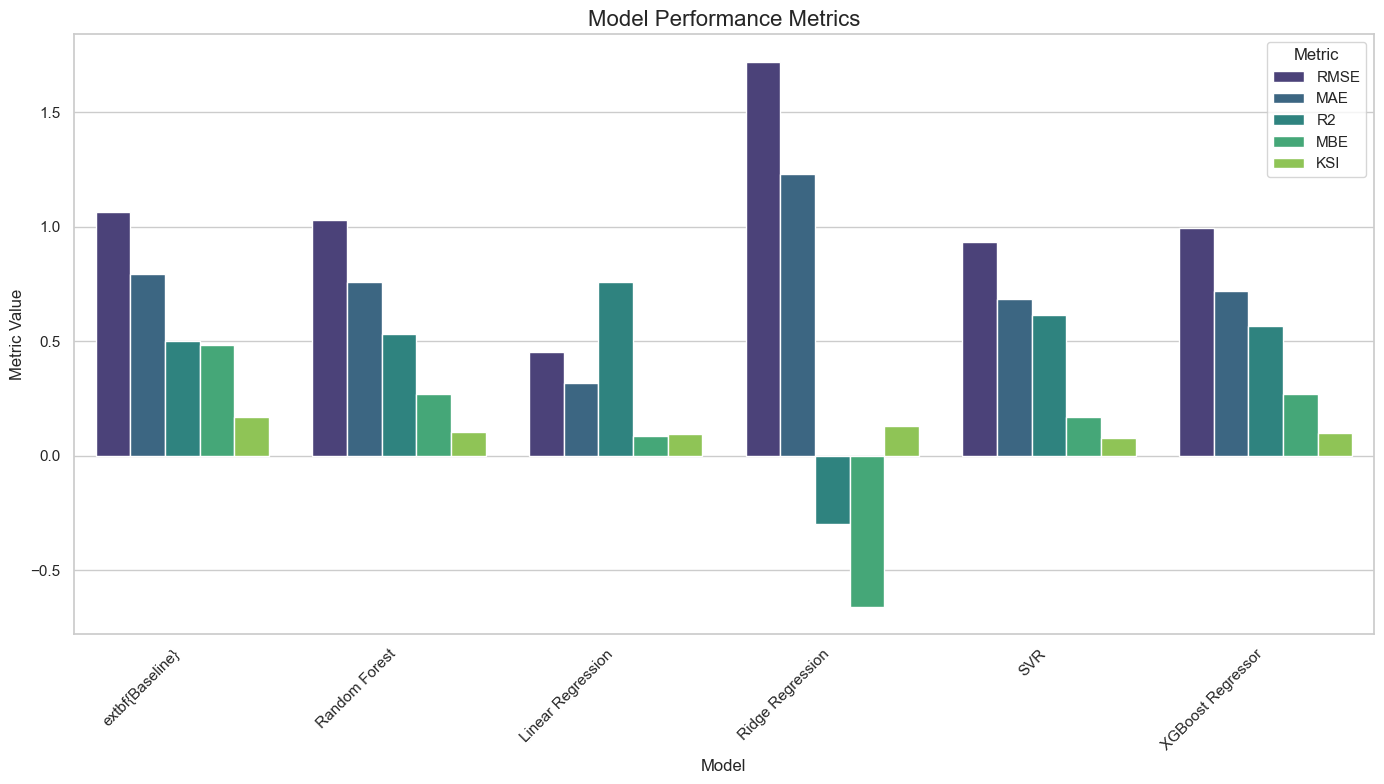

In [13]:
latex_text = """
\textbf{Baseline} & 1.0664 & 0.7945 & 0.5025 & 0.4852 & 0.1679 \\
\textbf{Random Forest} & 1.0319 & 0.7600 & 0.5341 & 0.2694 & 0.1039 \\
\textbf{Linear Regression} & 0.4526 & 0.3186 & 0.7592 & 0.0864 & 0.0968 \\
\textbf{Ridge Regression} & 1.7215 & 1.2321 & -0.2967 & -0.6590 & 0.1305 \\
\textbf{SVR} & 0.9354 & 0.6828 & 0.6171 & 0.1704 & 0.0757 \\
\textbf{XGBoost Regressor} & 0.9938 & 0.7216 & 0.5679 & 0.2693 & 0.1010 \\
"""
model_parameters = {
    'Random Forest': {'random_state': 42, 'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2},
    'Linear Regression': {},
    'Ridge Regression': {'random_state': 42, 'alpha': 100.0},
    'SVR': {'kernel': 'rbf', 'C': 1.0, 'epsilon': 0.1},
    'XGBoost Regressor': {'random_state': 42, 'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 5, 'colsample_bytree': 0.8, 'subsample': 0.8}
}

parse_and_plot_metrics(latex_text)

In [14]:
def scatter_plot_with_best_fit(data, ground_truth_col, est_ghi_col='ALLSKY_SFC_SW_DWN', prediction=None, title='Scatter Plot with Line of Best Fit'):
    """
    Creates a scatter plot with a line of best fit, optionally including a prediction comparison.

    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        ground_truth_col (str): The name of the ground truth column.
        est_ghi_col (str): The name of the estimated GHI column.
        prediction (pd.Series, optional): The predicted GHI values. Defaults to None.
        title (str, optional): The title of the plot. Defaults to 'Scatter Plot with Line of Best Fit'.
    """

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 row, 2 columns

    # --- Subplot 1: Estimated vs Ground Truth ---
    x = data[ground_truth_col]
    y_est = data[est_ghi_col]

    axes[0].scatter(x, y_est, alpha=0.5)

    # Line of best fit for estimated
    coefficients_est = np.polyfit(x, y_est, 1)
    line_of_best_fit_est = np.poly1d(coefficients_est)
    axes[0].plot(x, line_of_best_fit_est(x), color='red', label='Line of Best Fit')

    # Equation for estimated
    equation_est = f'y = {coefficients_est[0]:.2f}x + {coefficients_est[1]:.2f}'
    axes[0].text(0.1, 0.9, equation_est, transform=axes[0].transAxes, fontsize=12, color='red')

    axes[0].set_xlabel(ground_truth_col)
    axes[0].set_ylabel(est_ghi_col)
    axes[0].set_title(f'{est_ghi_col} vs {ground_truth_col}')
    axes[0].legend()
    axes[0].grid(True)


    # --- Subplot 2: Prediction vs Ground Truth ---
    if prediction is not None:
        y_pred = prediction
        axes[1].scatter(x, y_pred, alpha=0.5)

        # Line of best fit for prediction
        coefficients_pred = np.polyfit(x, y_pred, 1)
        line_of_best_fit_pred = np.poly1d(coefficients_pred)
        axes[1].plot(x, line_of_best_fit_pred(x), color='blue', label='Line of Best Fit')

        # Equation for prediction
        equation_pred = f'y = {coefficients_pred[0]:.2f}x + {coefficients_pred[1]:.2f}'
        axes[1].text(0.1, 0.9, equation_pred, transform=axes[1].transAxes, fontsize=12, color='blue')

        axes[1].set_xlabel(ground_truth_col)
        axes[1].set_ylabel('Predicted GHI')
        axes[1].set_title(f'Predicted GHI vs {ground_truth_col}')
        axes[1].legend()
        axes[1].grid(True)

    plt.suptitle(title, fontsize=16)  # Overall title
    plt.tight_layout()
    plt.show()

In [15]:
train_locations = ['ghana_location1', 'ghana_location2', 'kenya_location10',
                   'kenya_location13', 'kenya_location14', 'kenya_location2',
                   'kenya_location3', 'kenya_location4', 'kenya_location5',
                   'kenya_location6', 'kenya_location7', 'kenya_location8',
                   'madagascar_location1', 'madagascar_location2', 'nigeria_location1',
                   'nigeria_location2', 'nigeria_location3','wadelai']
test_locations = ['egypt_location1', 'ghana_location3', 'somalia_location1',
                  'soroti', 'kenya_location9', 'kenya_location11', 'kenya_location12',]
df_train_all = df[df['location'].isin(train_locations)].copy()
df_test_all = df[df['location'].isin(test_locations)].copy()

df_train_all['location'] = 'train_location'
df_test_all['location'] = 'test_location'

df_train_all = df_train_all.sort_index()
df_test_all = df_test_all.sort_index()
df_test_clean = df_test_all.copy()

df_test_clean = df_test_clean[parameters_array + ['ghi', 'location']]

### Linear Regression

Model loaded from models/

--- Evaluating Model Corrected GHI vs Ground Truth ---
--- LinearRegression Performance ---
RMSE: 3.6264
MAE:  2.3941
R²:   -4.9537
MBE:  0.8487
KSI:  0.3166
------------------------------------
Latex version
3.6264 & 2.3941 & -4.9537 & 0.8487 & 0.3166


--- Evaluating Original est GHI vs Ground Truth (Baseline) ---
--- Baseline (est GHI) Performance ---
RMSE: 1.3028
MAE:  0.9850
R²:   0.2316
MBE:  0.4411
KSI:  0.1618
--------------------------------------
Latex version
1.3028 & 0.9850 & 0.2316 & 0.4411 & 0.1618



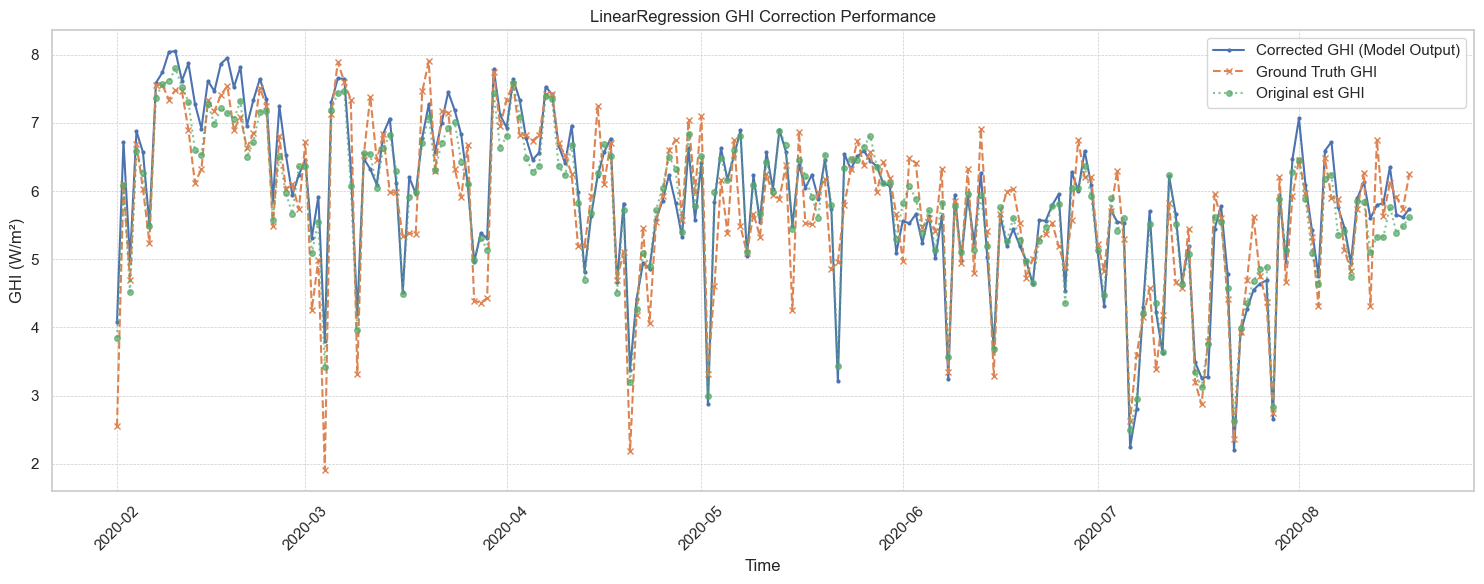

{'model_performance': {'RMSE': np.float64(3.6263972115029497),
  'MAE': 2.394080862168911,
  'R2': -4.953662634607216,
  'MBE': np.float64(0.8487281114369364),
  'KSI': np.float64(0.31661121064755565)},
 'baseline_performance': {'RMSE': np.float64(1.3028272892163326),
  'MAE': 0.9849941255012372,
  'R2': 0.23156494073488687,
  'MBE': np.float64(0.44108623880215003),
  'KSI': np.float64(0.16176094189915535)}}

In [16]:
linear_all_loc = create_linear_regression_model(
    est_ghi_col='ALLSKY_SFC_SW_DWN',
    ground_truth_col='ghi',
    feature_cols=parameters_array
)
model_dir = 'models/'
linear_all_loc.load_model(model_dir)
linear_all_loc.evaluate(df_test_clean, plot_results=True, num_plot_points=200, verbose=True)

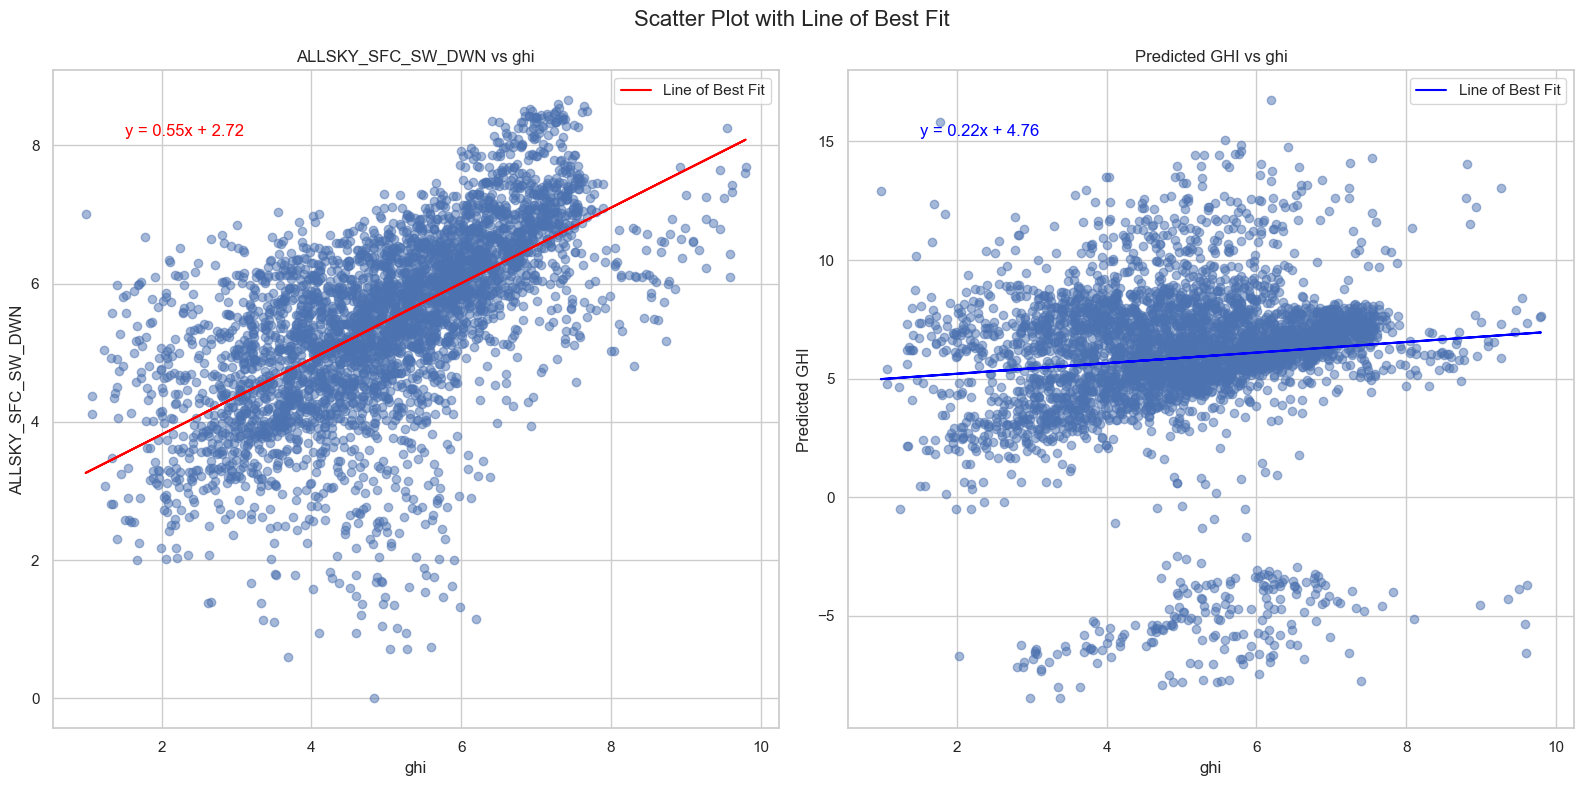

In [17]:
df_pred = linear_all_loc.predict(df_test_clean, return_error=False)
scatter_plot_with_best_fit(df_test_clean, ground_truth_col='ghi', prediction=df_pred)

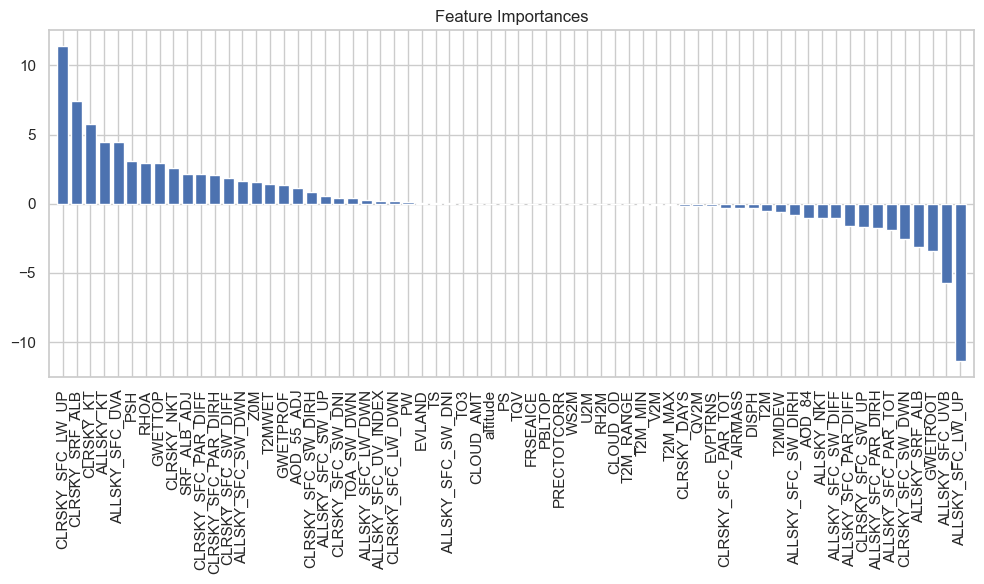

In [19]:
importances = linear_all_loc.model.coef_
feature_names = linear_all_loc.feature_cols
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.tight_layout()
plt.show()


### Ridge Regression

Model loaded from models/

--- Evaluating Model Corrected GHI vs Ground Truth ---
--- Ridge Performance ---
RMSE: 1.6577
MAE:  1.1645
R²:   -0.2440
MBE:  -0.4105
KSI:  0.1006
-------------------------
Latex version
1.6577 & 1.1645 & -0.2440 & -0.4105 & 0.1006


--- Evaluating Original est GHI vs Ground Truth (Baseline) ---
--- Baseline (est GHI) Performance ---
RMSE: 1.3028
MAE:  0.9850
R²:   0.2316
MBE:  0.4411
KSI:  0.1618
--------------------------------------
Latex version
1.3028 & 0.9850 & 0.2316 & 0.4411 & 0.1618



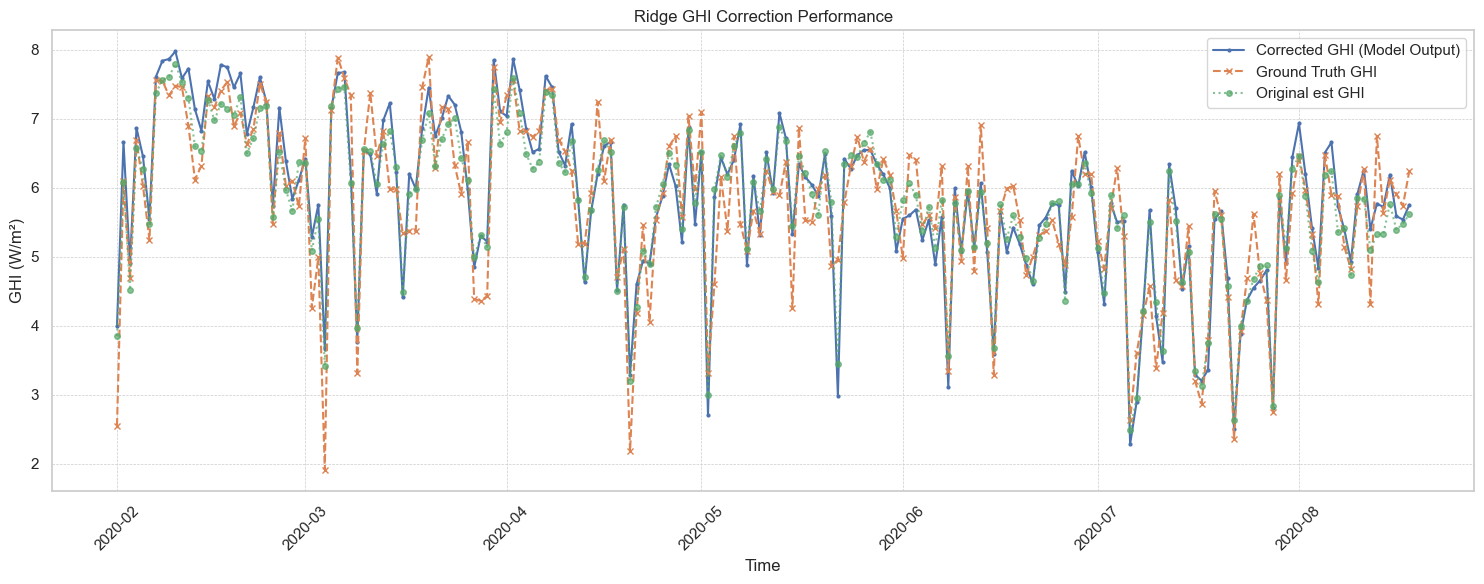

{'model_performance': {'RMSE': np.float64(1.6576733186144024),
  'MAE': 1.1645276571394994,
  'R2': -0.24403148490004645,
  'MBE': np.float64(-0.41045841990667614),
  'KSI': np.float64(0.10058868697210135)},
 'baseline_performance': {'RMSE': np.float64(1.3028272892163326),
  'MAE': 0.9849941255012372,
  'R2': 0.23156494073488687,
  'MBE': np.float64(0.44108623880215003),
  'KSI': np.float64(0.16176094189915535)}}

In [21]:
ridge_model = create_ridge_regression_model(
    feature_cols=parameters_array
)
ridge_model.load_model(model_dir)
ridge_model.evaluate(df_test_clean, plot_results=True, num_plot_points=200, verbose=True)

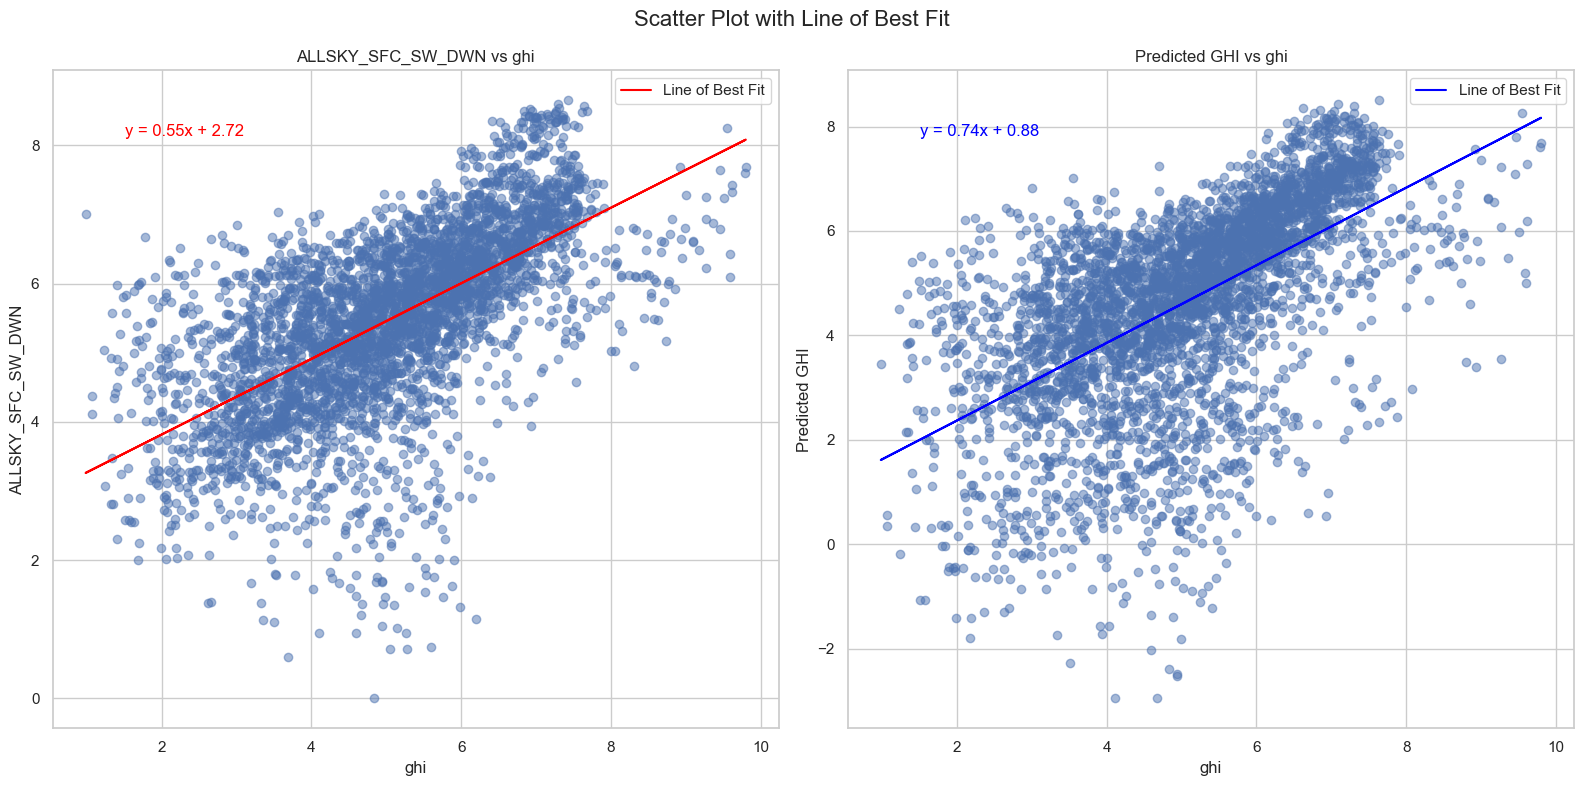

In [22]:
df_pred_ridge = ridge_model.predict(df_test_clean, return_error=False)
scatter_plot_with_best_fit(df_test_clean, ground_truth_col='ghi', prediction=df_pred_ridge)

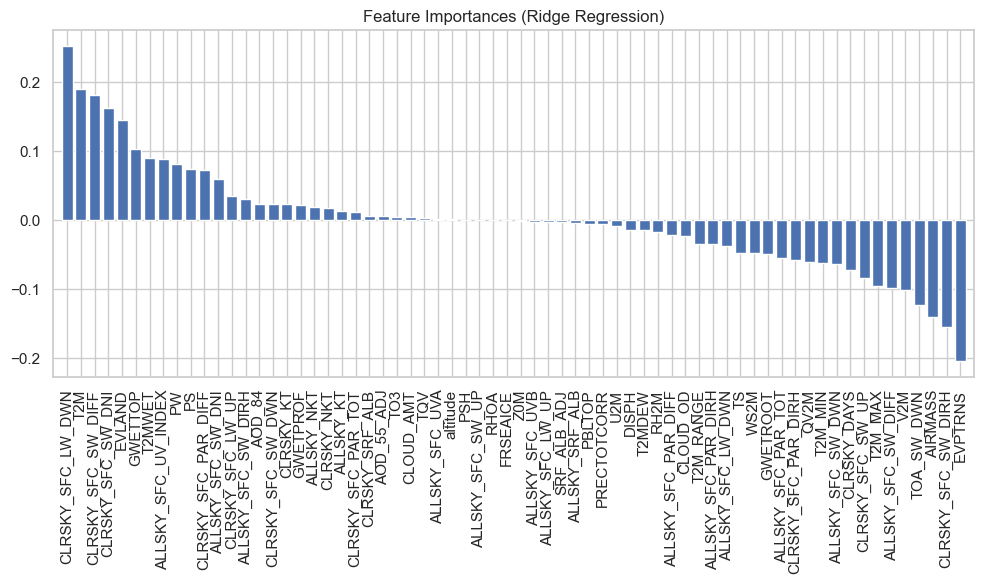

In [23]:
# feature importances
importances_ridge = ridge_model.model.coef_
feature_names_ridge = ridge_model.feature_cols
indices_ridge = np.argsort(importances_ridge)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Ridge Regression)")
plt.bar(range(len(importances_ridge)), importances_ridge[indices_ridge], align="center")
plt.xticks(range(len(importances_ridge)), np.array(feature_names_ridge)[indices_ridge], rotation=90)
plt.xlim([-1, len(importances_ridge)])
plt.tight_layout()
plt.show()

### SVR Model

In [24]:
# load svr model
svr_model = create_svr_model(
    feature_cols=parameters_array
)
svr_model.load_model(model_dir)

Model loaded from models/



--- Evaluating Model Corrected GHI vs Ground Truth ---
--- SVR Performance ---
RMSE: 1.2468
MAE:  0.9410
R²:   0.2962
MBE:  0.1242
KSI:  0.0819
-----------------------
Latex version
1.2468 & 0.9410 & 0.2962 & 0.1242 & 0.0819


--- Evaluating Original est GHI vs Ground Truth (Baseline) ---
--- Baseline (est GHI) Performance ---
RMSE: 1.3028
MAE:  0.9850
R²:   0.2316
MBE:  0.4411
KSI:  0.1618
--------------------------------------
Latex version
1.3028 & 0.9850 & 0.2316 & 0.4411 & 0.1618



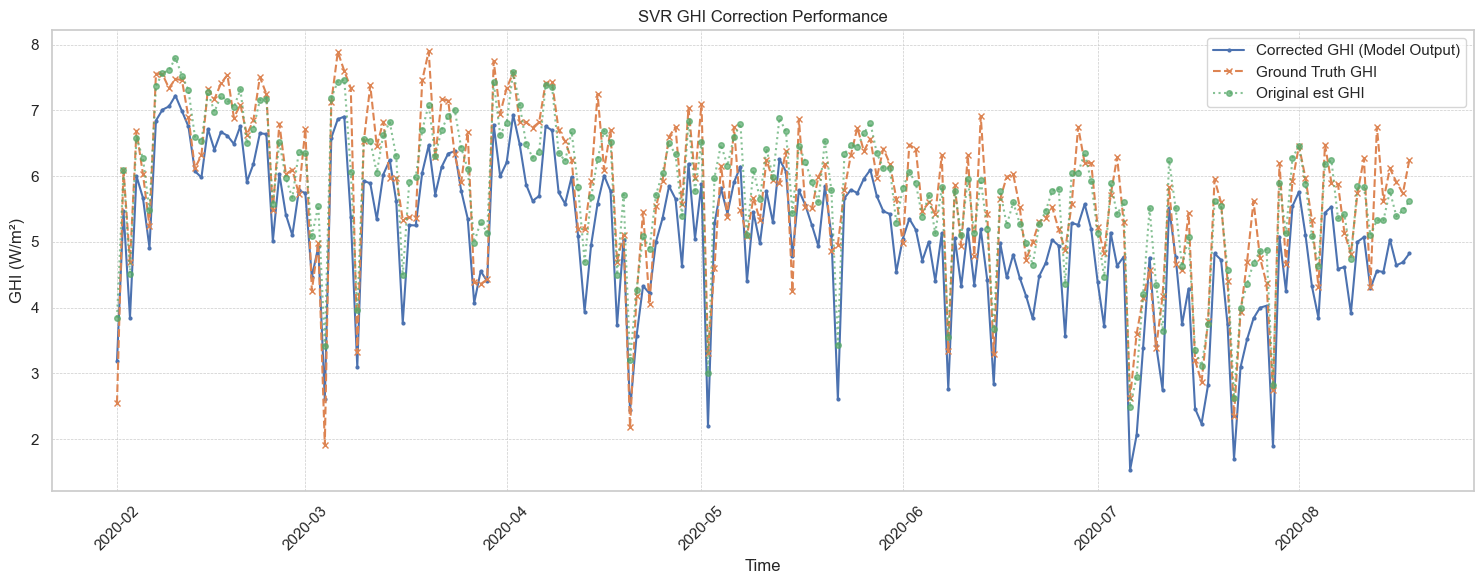

{'model_performance': {'RMSE': np.float64(1.2468354119811018),
  'MAE': 0.9409978132847532,
  'R2': 0.2961959944427529,
  'MBE': np.float64(0.12415777618075972),
  'KSI': np.float64(0.08190427437931917)},
 'baseline_performance': {'RMSE': np.float64(1.3028272892163326),
  'MAE': 0.9849941255012372,
  'R2': 0.23156494073488687,
  'MBE': np.float64(0.44108623880215003),
  'KSI': np.float64(0.16176094189915535)}}

In [25]:
svr_model.evaluate(df_test_clean, plot_results=True, num_plot_points=200, verbose=True) 

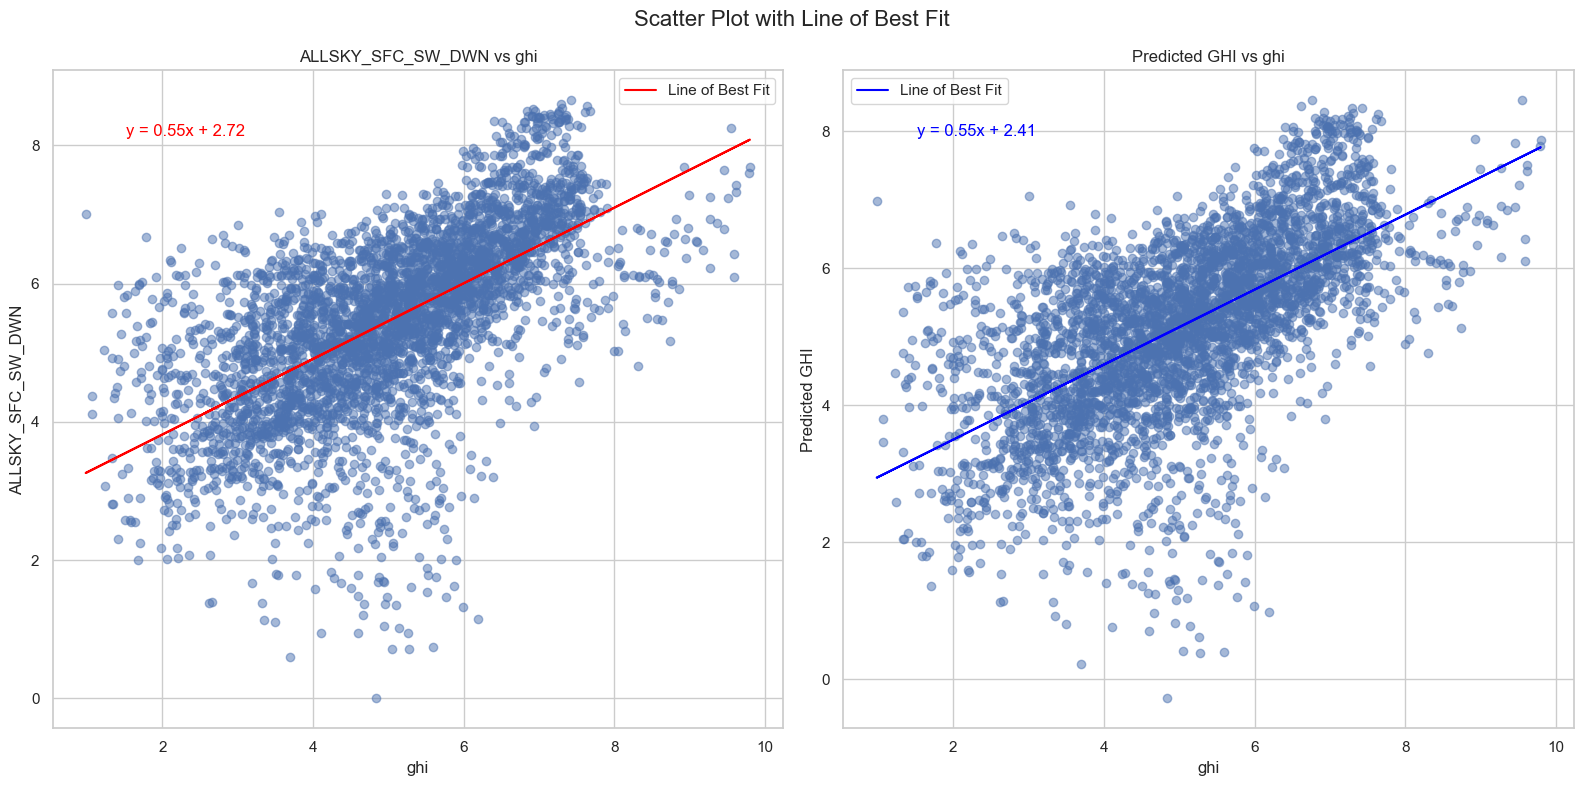

In [26]:
df_pred_svr = svr_model.predict(df_test_clean, return_error=False)
scatter_plot_with_best_fit(df_test_clean, ground_truth_col='ghi', prediction=df_pred_svr)

### Random Forest

Model loaded from models/

--- Evaluating Model Corrected GHI vs Ground Truth ---
--- RandomForestRegressor Performance ---
RMSE: 1.3320
MAE:  0.9930
R²:   0.1968
MBE:  0.3302
KSI:  0.1382
-----------------------------------------
Latex version
1.3320 & 0.9930 & 0.1968 & 0.3302 & 0.1382


--- Evaluating Original est GHI vs Ground Truth (Baseline) ---
--- Baseline (est GHI) Performance ---
RMSE: 1.3028
MAE:  0.9850
R²:   0.2316
MBE:  0.4411
KSI:  0.1618
--------------------------------------
Latex version
1.3028 & 0.9850 & 0.2316 & 0.4411 & 0.1618



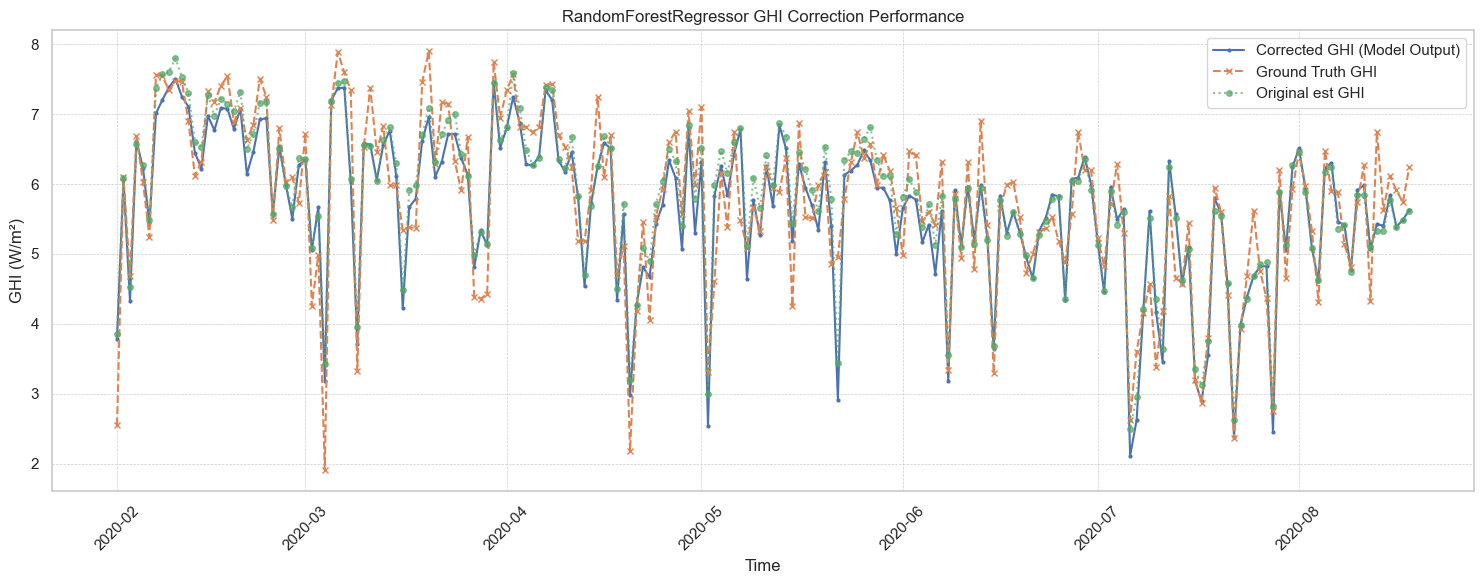

{'model_performance': {'RMSE': np.float64(1.3319765983516196),
  'MAE': 0.9929541151669676,
  'R2': 0.19679451253869518,
  'MBE': np.float64(0.3301680585767688),
  'KSI': np.float64(0.1382134630151011)},
 'baseline_performance': {'RMSE': np.float64(1.3028272892163326),
  'MAE': 0.9849941255012372,
  'R2': 0.23156494073488687,
  'MBE': np.float64(0.44108623880215003),
  'KSI': np.float64(0.16176094189915535)}}

In [28]:
random_forest_model = create_random_forest_model(
    feature_cols=parameters_array
)
random_forest_model.load_model(model_dir)
random_forest_model.evaluate(df_test_clean, plot_results=True, num_plot_points=200, verbose=True)

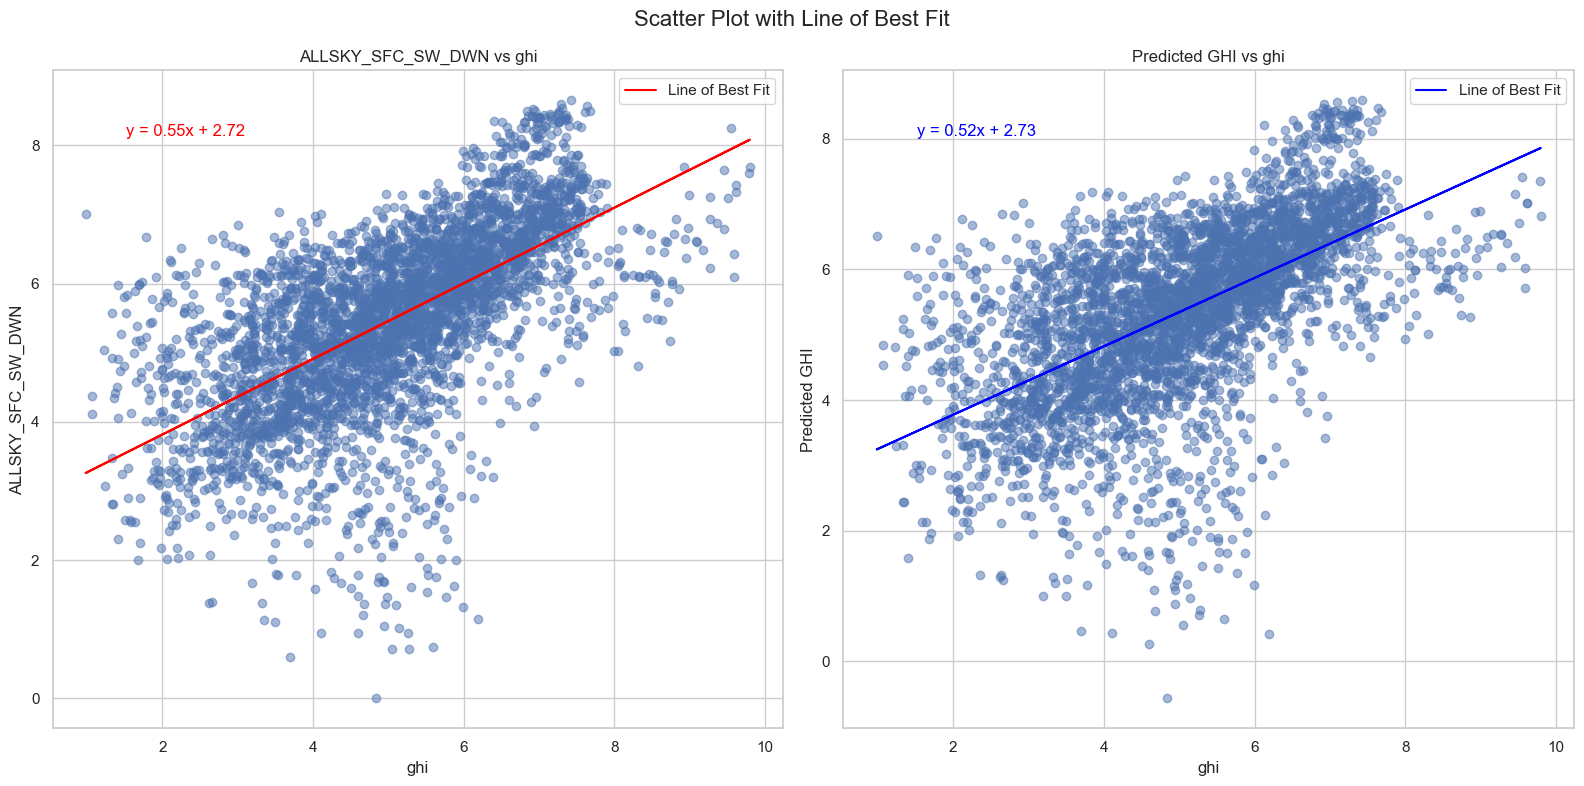

In [29]:
df_pred_rf = random_forest_model.predict(df_test_clean, return_error=False)
scatter_plot_with_best_fit(df_test_clean, ground_truth_col='ghi', prediction=df_pred_rf)

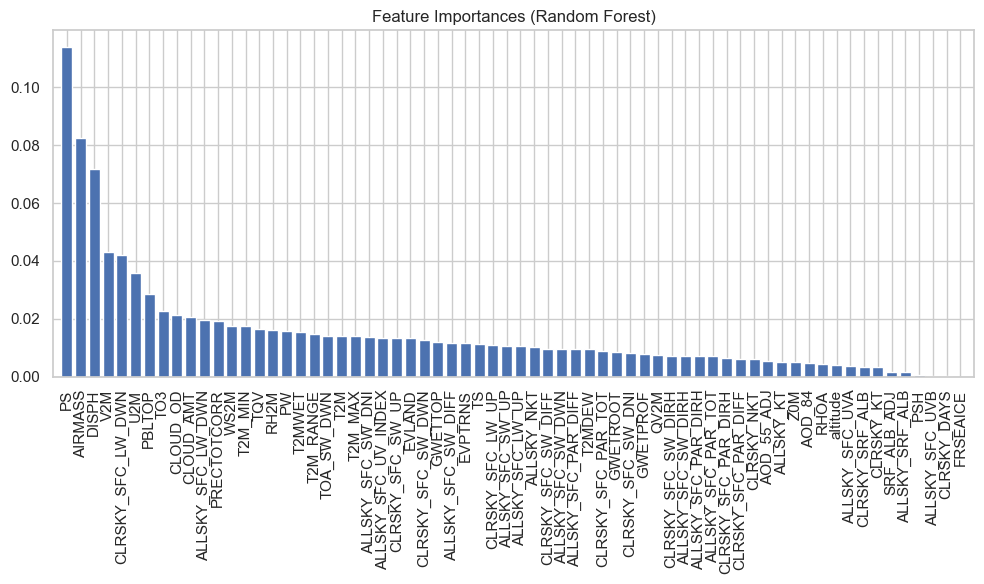

In [30]:
importances = random_forest_model.model.feature_importances_
feature_names = random_forest_model.feature_cols
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
xgboost_model = create_xgboost_model(
    feature_cols=parameters_array
)
xgboost_model.load_model(model_dir)
xgboost_model.evaluate(df_test_clean, plot_results=True, num_plot_points=200, verbose=True)

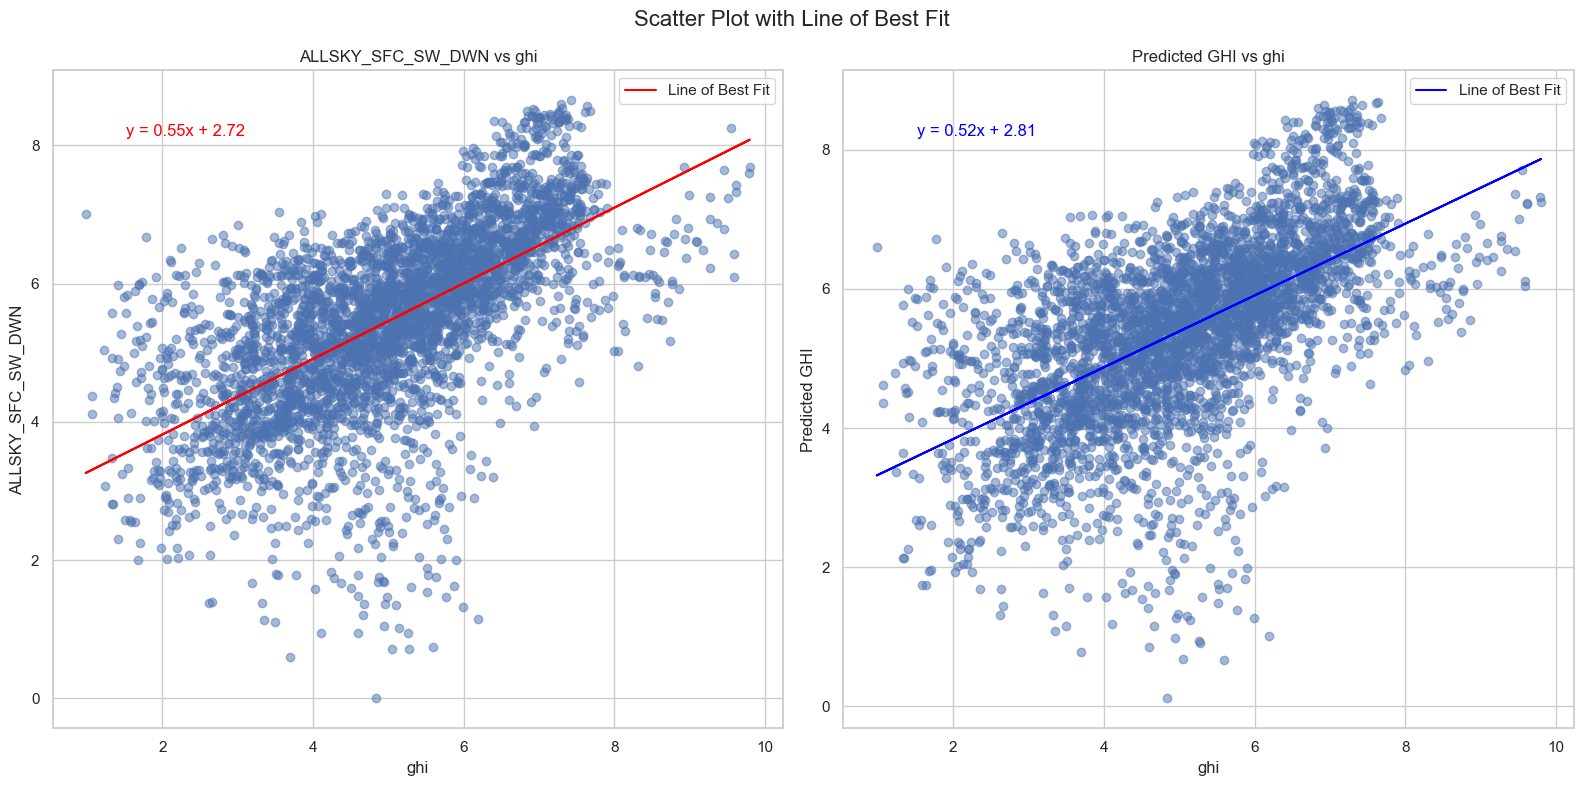

In [32]:
df_pred_xgboost = xgboost_model.predict(df_test_clean, return_error=False)
scatter_plot_with_best_fit(df_test_clean, ground_truth_col='ghi', prediction=df_pred_xgboost)

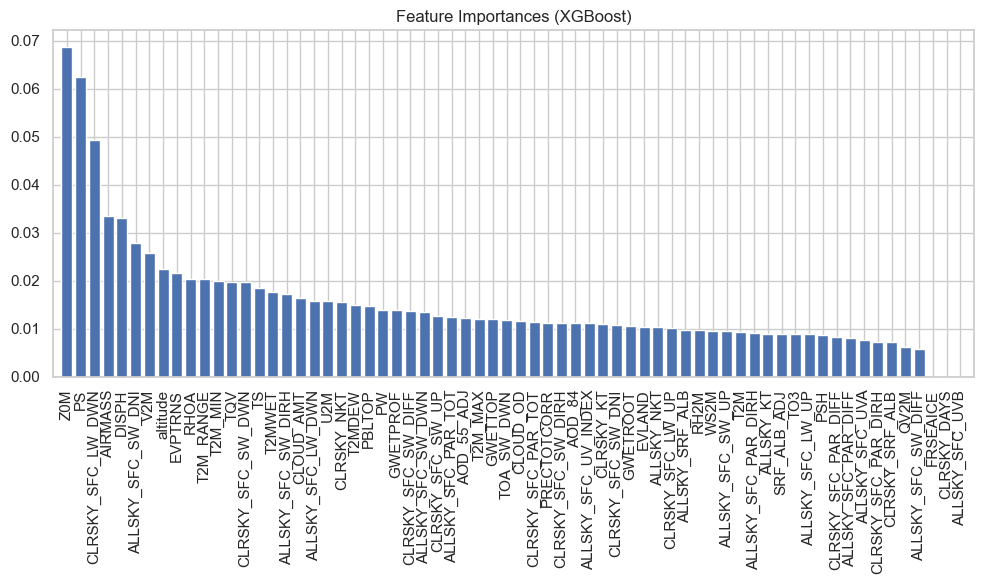

In [33]:
importances_xgb = xgboost_model.model.feature_importances_
feature_names_xgb = xgboost_model.feature_cols
indices_xgb = np.argsort(importances_xgb)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (XGBoost)")
plt.bar(range(len(importances_xgb)), importances_xgb[indices_xgb], align="center")
plt.xticks(range(len(importances_xgb)), np.array(feature_names_xgb)[indices_xgb], rotation=90)
plt.xlim([-1, len(importances_xgb)])
plt.tight_layout()
plt.show()